Imports 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 
plt.style.use("seaborn-v0_8")

Configuración de paths

In [ ]:
BASE       = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto")
DATA_PATH  = BASE / "data" / "processed" / "livvo_day_hotel_final.parquet"
OUTPUT_DIR = BASE / "notebooks" / "00_exploracion" / "peak_analysis" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Cargar datos del hotel 1

In [3]:
df = pd.read_parquet(DATA_PATH)
df = df[df["codigo_hotel"] == "HOTEL_1"].copy()
 
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
 
print("Rango temporal:", df["date"].min(), "→", df["date"].max())
df.head()

Rango temporal: 2023-01-01 00:00:00 → 2025-10-20 00:00:00


,date,codigo_hotel,roomnights,bednights,neto,stock,ocup_total,ADR
0,2023-01-01,HOTEL_1,48,97,5736.42,94,0.510638,119.508750
1,2023-01-02,HOTEL_1,62,116,6313.73,94,0.659574,101.834355
2,2023-01-03,HOTEL_1,59,104,5859.08,94,0.627660,99.306441
3,2023-01-04,HOTEL_1,63,112,6405.23,94,0.670213,101.670317
4,2023-01-05,HOTEL_1,65,106,7528.48,94,0.691489,115.822769


Visualización de la serie

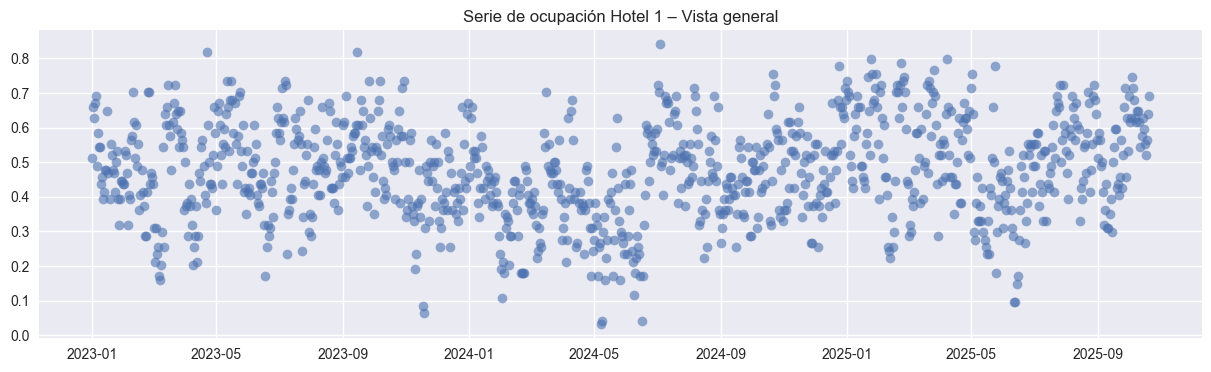

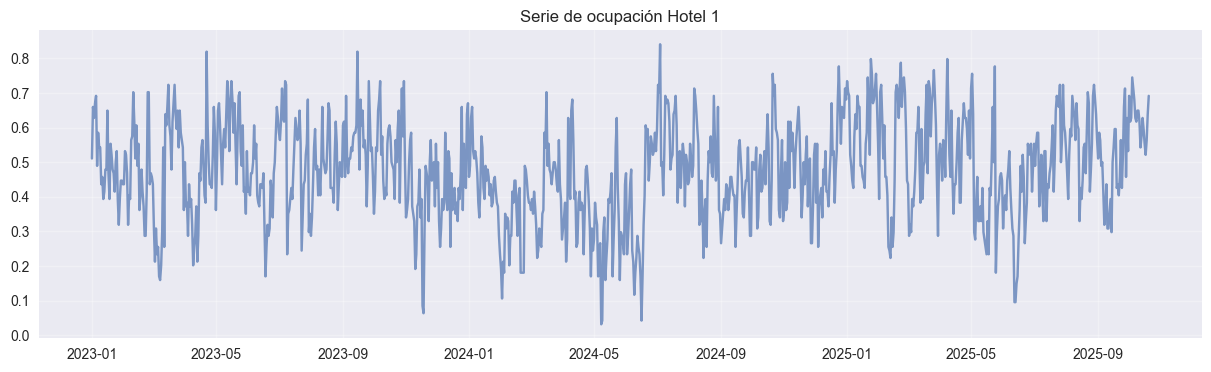

In [4]:
plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["ocup_total"], marker="o", linestyle="none", alpha=0.6)
plt.title("Serie de ocupación Hotel 1 – Vista general")
plt.show()
 
plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["ocup_total"], alpha=0.7)
plt.title("Serie de ocupación Hotel 1")
plt.grid(alpha=0.3)
plt.show()

Identificación de picos máximos históricos

In [5]:
TOP_N = 10
 
df_sorted = df.sort_values("ocup_total", ascending=False).reset_index(drop=True)
top_peaks = df_sorted.head(TOP_N)[["date", "ocup_total"]].copy()
 
top_peaks["dow"]   = top_peaks["date"].dt.dayofweek
top_peaks["month"] = top_peaks["date"].dt.month
top_peaks["week"]  = top_peaks["date"].dt.isocalendar().week.astype(int)
 
top_peaks

,date,ocup_total,dow,month,week
0,2024-07-04,0.840426,3,7,27
1,2023-04-22,0.819149,5,4,16
2,2023-09-15,0.819149,4,9,37
3,2025-01-24,0.797872,4,1,4
4,2025-04-08,0.797872,1,4,15
5,2025-02-22,0.787234,5,2,8
6,2025-05-24,0.776596,5,5,21
7,2024-12-24,0.776596,1,12,52
8,2025-03-26,0.765957,2,3,13
9,2024-10-21,0.755319,0,10,43


In [6]:
print("\n✅ FECHAS DE LOS PICOS DETECTADOS PARA HOTEL 1:\n")
for i, row in top_peaks.iterrows():
    print(f"{i+1}. {row['date'].date()} — ocupación: {row['ocup_total']:.3f}")


✅ FECHAS DE LOS PICOS DETECTADOS PARA HOTEL 1:

1. 2024-07-04 — ocupación: 0.840
2. 2023-04-22 — ocupación: 0.819
3. 2023-09-15 — ocupación: 0.819
4. 2025-01-24 — ocupación: 0.798
5. 2025-04-08 — ocupación: 0.798
6. 2025-02-22 — ocupación: 0.787
7. 2025-05-24 — ocupación: 0.777
8. 2024-12-24 — ocupación: 0.777
9. 2025-03-26 — ocupación: 0.766
10. 2024-10-21 — ocupación: 0.755



Añadir contexto real a cada pico identificado (Basado en la investigación y eventos reales de Las Palmas)


In [7]:
contexto_eventos = {
    "2024-07-04": "Festival musical internacional",
    "2023-04-22": "Festival Internacional de Cine de Las Palmas",
    "2025-02-22": "Carnaval de Las Palmas",
    "2024-12-24": "Navidad / Nochebuena",
    "2025-03-26": "Turismo primaveral (alta demanda)",
    "2025-04-08": "Semana Santa",
    "2025-05-24": "Pre-verano (demanda nacional)",
    "2024-10-21": "Eventos culturales / congresos",
    "2023-09-15": "Fin de verano",
    "2025-01-24": "Temporada alta invierno"
}
 
top_peaks["evento_real"] = top_peaks["date"].dt.strftime("%Y-%m-%d").map(contexto_eventos)
top_peaks["evento_real"] = top_peaks["evento_real"].fillna(
    "Alta demanda urbana (sin evento específico identificado)"
)
top_peaks

,date,ocup_total,dow,month,week,evento_real
0,2024-07-04,0.840426,3,7,27,Festival musical internacional
1,2023-04-22,0.819149,5,4,16,Festival Internacional de Cine de Las Palmas
2,2023-09-15,0.819149,4,9,37,Fin de verano
3,2025-01-24,0.797872,4,1,4,Temporada alta invierno
4,2025-04-08,0.797872,1,4,15,Semana Santa
5,2025-02-22,0.787234,5,2,8,Carnaval de Las Palmas
6,2025-05-24,0.776596,5,5,21,Pre-verano (demanda nacional)
7,2024-12-24,0.776596,1,12,52,Navidad / Nochebuena
8,2025-03-26,0.765957,2,3,13,Turismo primaveral (alta demanda)
9,2024-10-21,0.755319,0,10,43,Eventos culturales / congresos


Añadir la clasificación de eventos

In [8]:
event_type_map = {
    "Festival musical internacional":               "FIXED_DATE",
    "Navidad / Nochebuena":                         "FIXED_DATE",
    "Festival Internacional de Cine de Las Palmas": "MOVABLE_WINDOW",
    "Semana Santa":                                 "MOVABLE_WINDOW",
    "Carnaval de Las Palmas":                       "MOVABLE_WINDOW",
    "Fin de verano":                                "IRREGULAR"
}
 
top_peaks["event_date_type"] = top_peaks["evento_real"].map(event_type_map)
top_peaks["event_date_type"] = top_peaks["event_date_type"].fillna("FIXED_DATE")

Fechas equivalentes +1 y +2 años

In [9]:
top_peaks["fecha_equivalente_1y"] = top_peaks["date"] + pd.DateOffset(years=1)
top_peaks["fecha_equivalente_2y"] = top_peaks["date"] + pd.DateOffset(years=2)

Histórico auxiliar

In [10]:
df_hist = df[["date", "ocup_total"]].copy()
df_hist = df_hist.rename(columns={"date": "fecha_hist", "ocup_total": "ocup_total_real"})


Límite del histórico real

In [11]:
MAX_HIST_DATE = df["date"].max()
print("Última fecha con histórico real:", MAX_HIST_DATE.date())

Última fecha con histórico real: 2025-10-20


Valor real exacto (+1y y +2y) cuando hay datos

In [12]:
top_peaks = top_peaks.merge(
    df_hist, left_on="fecha_equivalente_1y", right_on="fecha_hist", how="left"
).rename(columns={"ocup_total_real": "ocup_total_real_equiv_1y"}).drop(columns=["fecha_hist"])
 
top_peaks = top_peaks.merge(
    df_hist, left_on="fecha_equivalente_2y", right_on="fecha_hist", how="left"
).rename(columns={"ocup_total_real": "ocup_total_real_equiv_2y"}).drop(columns=["fecha_hist"])

Búsqueda de pico real en ventana (eventos móviles)

In [13]:
WINDOW_DAYS = 7
 
def get_window_peak(center_date):
    mask = (
        (df["date"] >= center_date - pd.Timedelta(days=WINDOW_DAYS)) &
        (df["date"] <= center_date + pd.Timedelta(days=WINDOW_DAYS))
    )
    return df.loc[mask, "ocup_total"].max() if mask.any() else np.nan
 
top_peaks["ocup_total_real_window_1y"] = top_peaks.apply(
    lambda r: get_window_peak(r["fecha_equivalente_1y"])
    if (r["event_date_type"] == "MOVABLE_WINDOW" and r["fecha_equivalente_1y"] <= MAX_HIST_DATE)
    else np.nan,
    axis=1
)
 
top_peaks["ocup_total_real_window_2y"] = top_peaks.apply(
    lambda r: get_window_peak(r["fecha_equivalente_2y"])
    if (r["event_date_type"] == "MOVABLE_WINDOW" and r["fecha_equivalente_2y"] <= MAX_HIST_DATE)
    else np.nan,
    axis=1
)
 

Referencia real final

In [14]:
for col in ["ocup_total_real_equiv_1y", "ocup_total_real_equiv_2y",
            "ocup_total_real_window_1y", "ocup_total_real_window_2y"]:
    if col not in top_peaks.columns:
        top_peaks[col] = np.nan

VALIDACIÓN TEMPORAL REAL (+1 año / +2 años)

In [15]:
top_peaks["real_reference_1y"] = np.where(
    top_peaks["event_date_type"] == "MOVABLE_WINDOW",
    top_peaks["ocup_total_real_window_1y"],
    top_peaks["ocup_total_real_equiv_1y"]
)
 
top_peaks["real_reference_2y"] = np.where(
    top_peaks["fecha_equivalente_2y"] <= MAX_HIST_DATE,
    np.where(
        top_peaks["event_date_type"] == "MOVABLE_WINDOW",
        top_peaks["ocup_total_real_window_2y"],
        top_peaks["ocup_total_real_equiv_2y"]
    ),
    np.nan
)

Medir persistencia del pico

In [16]:
top_peaks["delta_real_1y"]     = top_peaks["real_reference_1y"] - top_peaks["ocup_total"]
top_peaks["delta_real_1y_pct"] = (top_peaks["delta_real_1y"] / top_peaks["ocup_total"]) * 100
top_peaks["delta_real_2y"]     = top_peaks["real_reference_2y"] - top_peaks["ocup_total"]
top_peaks["delta_real_2y_pct"] = (top_peaks["delta_real_2y"] / top_peaks["ocup_total"]) * 100
 
def clasificar_persistencia(x):
    if pd.isna(x):
        return "Pendiente de validar"
    elif x >= 0.05:
        return "✅ Peak consolidado"
    elif x <= -0.05:
        return "⚠️ Peak debilitado"
    return "Neutral"
 
top_peaks["status_peak"] = top_peaks["delta_real_1y"].apply(clasificar_persistencia)

Orden final y columnas clave

In [17]:
cols_final = [
    "date", "ocup_total", "evento_real", "event_date_type",
    "fecha_equivalente_1y", "fecha_equivalente_2y",
    "real_reference_1y", "real_reference_2y",
    "delta_real_1y", "delta_real_1y_pct",
    "delta_real_2y", "delta_real_2y_pct",
    "status_peak"
]
 
top_peaks = top_peaks[cols_final].sort_values("ocup_total", ascending=False)
top_peaks.head()

,date,ocup_total,evento_real,event_date_type,fecha_equivalente_1y,fecha_equivalente_2y,real_reference_1y,real_reference_2y,delta_real_1y,delta_real_1y_pct,delta_real_2y,delta_real_2y_pct,status_peak
0,2024-07-04,0.840426,Festival musical internacional,FIXED_DATE,2025-07-04,2026-07-04,0.585106,NaN,-0.255319,-30.379747,NaN,NaN,⚠️ Peak debilitado
1,2023-04-22,0.819149,Festival Internacional de Cine de Las Palmas,MOVABLE_WINDOW,2024-04-22,2025-04-22,0.489362,0.670213,-0.329787,-40.259740,-0.148936,-18.181818,⚠️ Peak debilitado
2,2023-09-15,0.819149,Fin de verano,IRREGULAR,2024-09-15,2025-09-15,0.255319,0.500000,-0.563830,-68.831169,-0.319149,-38.961039,⚠️ Peak debilitado
3,2025-01-24,0.797872,Temporada alta invierno,FIXED_DATE,2026-01-24,2027-01-24,NaN,NaN,NaN,NaN,NaN,NaN,Pendiente de validar
4,2025-04-08,0.797872,Semana Santa,MOVABLE_WINDOW,2026-04-08,2027-04-08,NaN,NaN,NaN,NaN,NaN,NaN,Pendiente de validar


Export para dashboard

In [18]:
output_path = OUTPUT_DIR / "peak_Hotel1.parquet"
top_peaks.to_parquet(output_path, index=False)
print("✅ Peak dataset guardado en:", output_path)

✅ Peak dataset guardado en: C:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\notebooks\00_exploracion\peak_analysis\outputs\peak_Hotel1.parquet


Visualización

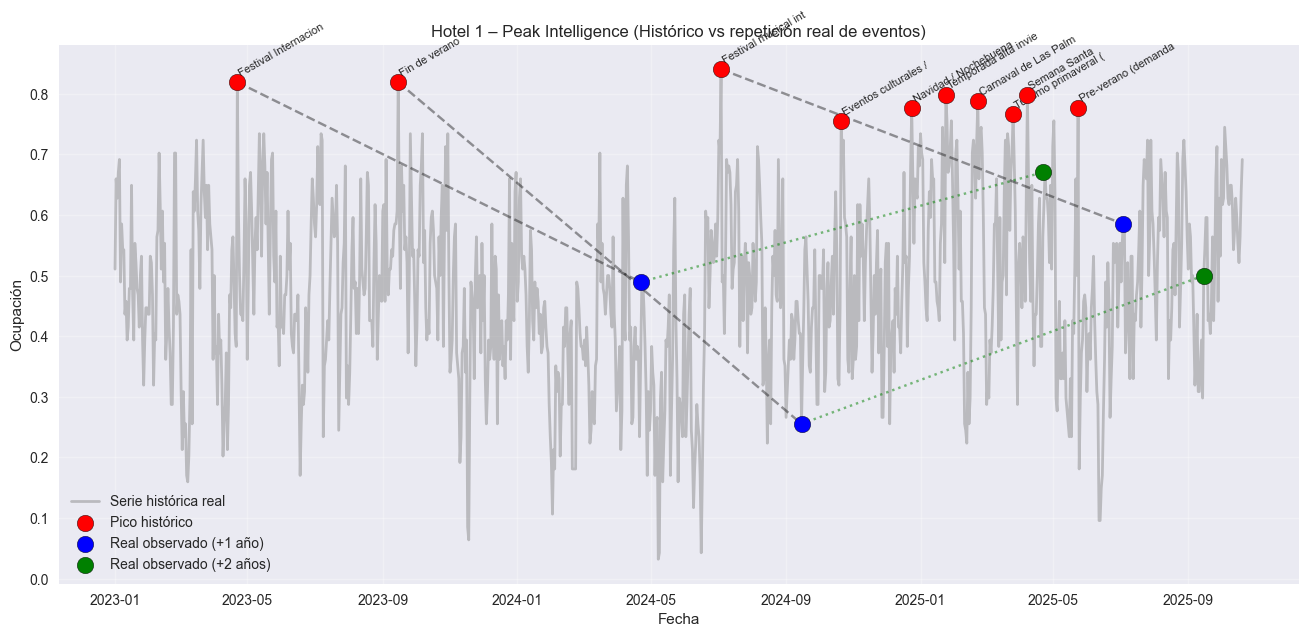

In [19]:
plt.figure(figsize=(16, 7))
 
plt.plot(df["date"], df["ocup_total"],
         color="gray", alpha=0.45, linewidth=2, label="Serie histórica real")
 
plt.scatter(top_peaks["date"], top_peaks["ocup_total"],
            color="red", s=140, edgecolor="black", zorder=5, label="Pico histórico")
 
mask_real_1y = top_peaks["real_reference_1y"].notna()
plt.scatter(
    top_peaks.loc[mask_real_1y, "fecha_equivalente_1y"],
    top_peaks.loc[mask_real_1y, "real_reference_1y"],
    color="blue", s=140, edgecolor="black", zorder=5, label="Real observado (+1 año)"
)
for _, r in top_peaks.loc[mask_real_1y].iterrows():
    plt.plot([r["date"], r["fecha_equivalente_1y"]],
             [r["ocup_total"], r["real_reference_1y"]],
             color="black", linestyle="--", alpha=0.4)
 
mask_real_2y = top_peaks["real_reference_2y"].notna()
plt.scatter(
    top_peaks.loc[mask_real_2y, "fecha_equivalente_2y"],
    top_peaks.loc[mask_real_2y, "real_reference_2y"],
    color="green", s=140, edgecolor="black", zorder=5, label="Real observado (+2 años)"
)
for _, r in top_peaks.loc[mask_real_2y].iterrows():
    plt.plot([r["fecha_equivalente_1y"], r["fecha_equivalente_2y"]],
             [r["real_reference_1y"], r["real_reference_2y"]],
             color="green", linestyle=":", alpha=0.5)
 
for _, r in top_peaks.iterrows():
    plt.text(r["date"], r["ocup_total"] + 0.01,
             r["evento_real"][:20], fontsize=8, rotation=30)
 
plt.title("Hotel 1 – Peak Intelligence (Histórico vs repetición real de eventos)")
plt.xlabel("Fecha")
plt.ylabel("Ocupación")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# CONCLUSIÓN FINAL – PEAK INTELLIGENCE DEL HOTEL 1 (URBANO)

En este análisis he construido un sistema de Peak Intelligence específico para el Hotel 1, cuyo objetivo es:

1. Identificar los picos máximos de ocupación histórica.
2. Investigar qué eventos reales ocurrieron en Las Palmas de Gran Canaria en esas fechas, para entender la causa de esos picos.
3. Comparar ambos valores reales para medir riesgo, estabilidad u oportunidad.
4. Dejar un dataset estandarizado para integrarlo en el dashboard final del proyecto.

Este enfoque aporta un valor que ningún modelo predictivo ofrece por sí mismo, ya que combina:

- análisis estadístico,
- contexto real urbano,
- y explicación operacional.


## Resumen del Desarrollo y Planteamiento del Código

El notebook de Peak Intelligence se ha desarrollado siguiendo una lógica estructurada, incremental y metodológicamente conservadora, diseñada para garantizar trazabilidad, robustez analítica y coherencia entre datos históricos, contexto real y proyección futura.

### 1. Importación de datos y preparación

Se carga el dataset consolidado (`livvo_day_hotel_final.parquet`) y se filtran exclusivamente las observaciones correspondientes al Hotel 1. La columna de fecha se estandariza, la serie se ordena temporalmente y se realiza una validación visual inicial de la ocupación.

Este paso garantiza partir de una serie **limpia, continua y libre de supuestos artificiales**, condición imprescindible para una detección fiable de picos máximos.

### 2. Identificación de picos máximos

La detección de picos se realiza **ordenando los días por ocupación descendente** y seleccionando los **TOP‑10 valores máximos reales**, sin aplicar umbrales heurísticos.

A cada pico se le incorporan variables temporales (día de la semana, mes y semana ISO) que permiten analizar patrones de calendario, sin asumir estacionalidad previa.

Este enfoque es especialmente adecuado para hoteles urbanos como el Hotel 1, donde no existe una estacionalidad dominante y los máximos aparecen como episodios discretos.

### 3. Investigación documental y asociación de eventos reales

Cada pico identificado se contrasta manualmente con eventos reales ocurridos en Las Palmas de Gran Canaria mediante un análisis documental apoyado en fuentes verificadas.

Los eventos asociados incluyen festivales, celebraciones culturales, carnaval, cine internacional, festividades insulares, periodos vacacionales y congresos.

Este paso introduce **explicabilidad contextual**, permitiendo interpretar cada pico no como una anomalía estadística, sino como consecuencia directa de un estímulo urbano identificable.

### 4. Tipología de eventos y criterios de comparación

Con base en el análisis contextual, los picos se clasifican en tres tipologías conceptuales:

- **FIXED_DATE**: eventos de fecha estable (por ejemplo, Navidad).
- **MOVABLE_WINDOW**: eventos recurrentes con desplazamiento en calendario (por ejemplo, Festival Internacional de Cine, Semana Santa, Carnaval).
- **IRREGULAR**: episodios no estructurales ni repetibles (por ejemplo, Fin de verano).

Esta clasificación no es descriptiva, sino operativa, ya que define **cómo se construye la referencia real futura** en las comparaciones temporales.

### 5. Definición de fechas equivalentes (+1 año y +2 años)

Para cada pico se calculan dos horizontes temporales:

- **fecha_equivalente_1y** = fecha del pico + 1 año
- **fecha_equivalente_2y** = fecha del pico + 2 años

La comparación a **+2 años solo se realiza cuando el histórico real lo permite**, evitando introducir información no observada:

- Picos de 2024 → evaluables únicamente a +1 año (2025).
- Picos de 2023 → evaluables a +1 año (2024) y +2 años (2025).

### 6. Ventana temporal para eventos de fecha móvil

En eventos clasificados como **MOVABLE_WINDOW**, especialmente el Festival Internacional de Cine de Las Palmas, la fecha exacta del evento varía cada año.

Para evitar comparaciones erróneas basadas en un día fijo, se define una **ventana temporal de ±7 días** alrededor de la fecha equivalente. La referencia real se obtiene como el **máximo de ocupación observado dentro de esa ventana temporal**, siempre que el histórico exista.

Este enfoque captura correctamente el impacto real del evento, sin forzar alineaciones artificiales, y mantiene el rigor metodológico.

En los eventos **IRREGULAR**, no se utiliza ventana temporal; la comparación se realiza únicamente como referencia contextual del comportamiento futuro.

### 7. Dataset final y visualización integrada

El proceso culmina con la generación del dataset `peak_Hotel1.parquet`, que consolida:

- pico histórico y ocupación real,
- evento urbano asociado y tipología,
- ocupación real observada a +1 y +2 años cuando existe histórico,
- métricas de error y clasificación de riesgo.

La visualización final integra en una sola gráfica:

- 🔴 Pico histórico
- 🔵 Real observado a +1 año
- 🟢 Real observado a +2 años

con conexiones temporales que permiten interpretar de forma inmediata la transición entre evento y realidad observada.


## Conclusiones del Análisis

### 1. Los picos de ocupación del Hotel 1 son completamente evento‑dependientes

Todos los picos máximos de ocupación identificados están asociados a **eventos urbanos extraordinarios** verificables.

No se observa evidencia de una estacionalidad estructural capaz de explicar los máximos por sí sola. El Hotel 1 presenta un comportamiento estable durante el año y únicamente alcanza niveles excepcionales de ocupación cuando existe un estímulo externo concreto.

### 2. La validación ex‑post a +1 y +2 años refuerza la robustez del análisis

A diferencia de un enfoque puramente prospectivo, este análisis incorpora una validación ex‑post real cuando el horizonte temporal lo permite.

Los resultados muestran que:

- En eventos de fecha móvil como el **Festival Internacional de Cine**, la utilización de una ventana temporal permite capturar correctamente el impacto real del evento, tanto a +1 como a +2 años.
- En eventos **irregulares** como el Fin de verano, los valores reales observados a +1 y +2 años presentan una elevada variabilidad, confirmando la ausencia de un patrón repetible.

### 3. Algunos picos presentan riesgo estructural de caída

La comparación entre picos históricos y realidad observada conduce a una conclusión clara:

⚠️ **Varios picos presentan riesgo de caída.**

Esto implica que:

- no debe asumirse la repetición automática de picos en fechas similares,
- la alta demanda solo reaparece si el evento se confirma explícitamente,
- la estrategia de precios y revenue debe ser específica por fecha y contexto.

### 4. Implicaciones operativas para un hotel urbano como el Hotel 1

El Hotel 1 funciona bajo un régimen de ocupación estable, con incrementos puntuales ligados a eventos concretos.

Este hallazgo es consistente con:

- el análisis exploratorio inicial,
- el proceso de selección y validación del modelo,
- la baja estacionalidad observada,
- y la importancia de las variables de calendario y contexto urbano.

En consecuencia, la planificación comercial y estratégica del hotel debe apoyarse en **inteligencia contextual**, no en patrones históricos asumidos.


## Bibliografía (Evidencia verificable)

### 04/07/2024 – Festival musical internacional

Festival TEMUDAS + macrofestival del 4 al 6 julio con artistas internacionales [quehacerlaspalmas.com](https://quehacerlaspalmas.com/agenda-cultural-para-arrancar-el-mes-de-julio-en-las-palmas-de-gran-canaria/#google_vignette)

### 22/04/2023 – Festival Internacional de Cine

Proyección oficial el 22 abril 2023 en Cinesa El Muelle [happeningnext.com](https://happeningnext.com/event/la-tara-en-las-palmas-de-gran-canaria-international-film-festival-eid3a0a1qoo9s)

- **2023** – del 14 al 23 de abril
- **2024** – del 19 al 28 de abril
- **2025** – del 25 de abril al 4 de mayo

Estas referencias justifican el desplazamiento anual del evento y el uso de una **ventana temporal de ±7 días** en los análisis realizados a +1 y +2 años.

### 15/09/2023 – Fin de verano / fiestas insulares

Semana del 9 al 15 septiembre con fiestas, música y deporte en Canarias [rtvc.es](https://rtvc.es/recomendaciones-culturales-segunda-semana-de-septiembre/)

### 24/01/2025 – Almendro en Flor

Festival Almond Blossom de Valsequillo entre 24–26 enero 2025 [valsequillogc.es](https://www.valsequillogc.es/ayto3/download/programa-de-la-ruta-del-almendrero-en-flor-2025/)

### 08/04/2025 – Semana Santa

Procesiones desde el 13 abril en Vegueta y Triana; eventos previos desde el 8 abril [quehacerlaspalmas.com](https://quehacerlaspalmas.com/abril-de-2025-agenda-cultural-y-de-ocio-en-las-palmas-de-gran-canaria/#google_vignette)

### 22/02/2025 – Carnaval (Final Murgas)

Final de Murgas el 22 febrero 2025 según programa oficial del Carnaval [guidetocanaryislands.com](https://www.guidetocanaryislands.com/las-palmas-de-gran-canaria-carnival/#google_vignette)

### 24/05/2025 – Pre‑verano

Actividad cultural y talleres en Las Palmas durante mayo 2025 [quehacerlaspalmas.com](https://quehacerlaspalmas.com/agenda-cultural-de-gran-canaria-mayo-de-2025/)

### 24/12/2024 – Navidad / Nochebuena

Pistas de hielo, mercadillos y planes familiares entre 23–29 diciembre 2024 [laprovincia.es](https://www.laprovincia.es/gran-canaria/2024/12/26/siete-planes-gratuitos-pasar-ultimo-112924584.html)

### 26/03/2025 – Turismo primaveral

Agenda cultural del Cabildo de Gran Canaria en marzo 2025 [quehacerlaspalmas.com](https://quehacerlaspalmas.com/agenda-cultural-del-cabildo-de-gran-canaria-marzo-2025/)

### 21/10/2024 – Eventos culturales / University On Tour

Evento "University On Tour" el 21 octubre 2024 [universityontour.com](https://universityontour.com/eventos/)

Semana del 21–27 octubre llena de actividades culturales [rtvc.es](https://rtvc.es/planes-en-canarias-del-21-al-27-de-octubre-2024/)